# Multistep amperometry: −40 °C pyrrole, fixed-length, aqueous (2026-05-06)

Pairs the scope force-sensor log with the potentiostat amperometry trace.
Plots time on the **Y** axis so both signals run vertically with a common time origin.

- Scope: `scope_log_20260506_fixed_length_variable_force_5xgain.csv` (5× gain → **5.67 mN/V**)
- Potentiostat: `data_from_potentiostat/05.06.25-neg40C-pyrrole-fixed-length-aqueous.csv` (`MultiStep Amperometry: i vs t`, columns `s, µA`)

Sample geometry: **3 mm × 0.0360 mm = 0.108 mm²** (so stress = force / 0.108 mm² in MPa).

Scope started before the potentiostat measurement — the load cell prints the actual offset from metadata.

In [29]:
# Load both files and align them on a common 'experiment time' axis (t_exp).
# t_exp = 0 when the potentiostat measurement starts.

import os
import io
import csv
import numpy as np
import pandas as pd
from datetime import datetime

SCOPE_CSV = 'scope_log_20260506_fixed_length_variable_force_5xgain.csv'
POTEN_CSV = 'data_from_potentiostat/05.06.25-neg40C-pyrrole-fixed-length-aqueous.csv'

# Offset override. If None, we auto-derive (potentiostat_start - scope_start)
# from the file metadata. If set to a number, that value (in seconds) is used
# instead — positive means scope was started this many seconds before the
# potentiostat measurement.
OFFSET_OVERRIDE_S = 150


# ---- 1. Potentiostat (UTF-16, MultiStep Amperometry: t,i columns) ----
with open(POTEN_CSV, 'rb') as f:
    text = f.read().decode('utf-16').replace('﻿', '')
lines = text.splitlines()
poten_start_str = lines[4].split(',')[1].strip()
poten_start = datetime.strptime(poten_start_str, '%Y-%m-%d %H:%M:%S')
data_rows = list(csv.reader(io.StringIO('\n'.join(lines[6:]))))
data_rows = [r for r in data_rows if len(r) >= 2 and r[0]]
poten = pd.DataFrame(data_rows, columns=['t_s', 'i_uA']).astype(float)
poten_total_s = float(poten['t_s'].max())


# ---- 2. Scope log + time alignment ----
scope = pd.read_csv(SCOPE_CSV)
scope_start = (datetime.fromisoformat(scope['timestamp'].iloc[0])
               - pd.Timedelta(seconds=float(scope['elapsed_s'].iloc[0])))
metadata_offset_s = (poten_start - scope_start).total_seconds()
offset_s = OFFSET_OVERRIDE_S if OFFSET_OVERRIDE_S is not None else metadata_offset_s

print(f'Scope start:        {scope_start}')
print(f'Potentiostat start: {poten_start}')
print(f'Offset from metadata: {metadata_offset_s:.2f} s')
if OFFSET_OVERRIDE_S is not None:
    print(f'Using manual override:  {offset_s:.2f} s')
print(f'Potentiostat duration: {poten_total_s:.1f} s')

scope['t_exp'] = scope['elapsed_s'] - offset_s
scope_clean = scope[(scope['t_exp'] >= 0) & (scope['t_exp'] <= poten_total_s)].copy()
scope_clean = scope_clean.sort_values('t_exp').reset_index(drop=True)
print(f'Scope rows in experiment window: {len(scope_clean)} / {len(scope)}')
scope_clean.head()


Scope start:        2026-05-06 13:57:06.358928
Potentiostat start: 2026-05-06 14:01:11
Offset from metadata: 244.64 s
Using manual override:  150.00 s
Potentiostat duration: 2000.0 s
Scope rows in experiment window: 7781 / 8494


,elapsed_s,timestamp,ch1_MEAN_V,ch2_MEAN_V,t_exp
0,150.199,2026-05-06T13:59:36.557970,0.0,5.82,0.199
1,150.451,2026-05-06T13:59:36.810014,0.0,5.82,0.451
2,150.707,2026-05-06T13:59:37.066220,0.0,5.82,0.707
3,150.959,2026-05-06T13:59:37.318055,0.0,5.82,0.959
4,151.231,2026-05-06T13:59:37.590074,0.0,5.82,1.231


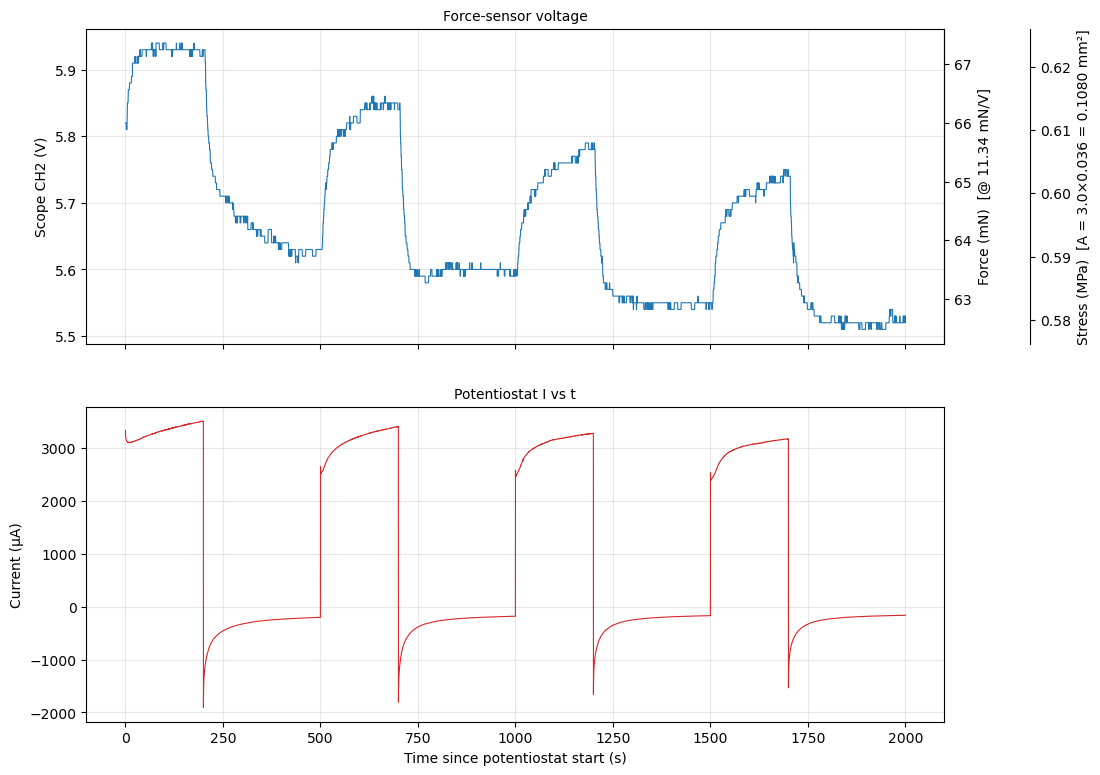

In [30]:
# Stacked plot, shared X-axis (time, seconds since potentiostat start).
# Top:    scope CH2 voltage, with extra Y axes for force (mN) and stress (MPa) on the right.
# Bottom: potentiostat current (µA).

import matplotlib.pyplot as plt

# --- Sample geometry / calibration ---
FORCE_GAIN_MN_PER_V = 11.34     # 5x scope gain
THICKNESS_MM = 0.0360 
WIDTH_MM = 3.0
AREA_MM2 = THICKNESS_MM * WIDTH_MM   # 0.108 mm^2
STRESS_PER_V_MPA = FORCE_GAIN_MN_PER_V / 1000.0 / AREA_MM2

fig, (ax_v, ax_i) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# --- Top: time on X, scope CH2 voltage on Y ---
ax_v.plot(scope_clean['t_exp'], scope_clean['ch2_MEAN_V'], color='#1f77b4', lw=0.8)
ax_v.set_ylabel('Scope CH2 (V)')
ax_v.set_title('Force-sensor voltage', fontsize=10)
ax_v.grid(True, alpha=0.3)

# Secondary Y axes (right): force (mN), then stress (MPa) offset further right
ax_v_force = ax_v.secondary_yaxis(
    'right',
    functions=(lambda v: v * FORCE_GAIN_MN_PER_V, lambda mn: mn / FORCE_GAIN_MN_PER_V),
)
ax_v_force.set_ylabel(f'Force (mN)  [@ {FORCE_GAIN_MN_PER_V} mN/V]')

ax_v_stress = ax_v.secondary_yaxis(
    1.10,
    functions=(lambda v: v * STRESS_PER_V_MPA, lambda mpa: mpa / STRESS_PER_V_MPA),
)
ax_v_stress.set_ylabel(
    f'Stress (MPa)  [A = {WIDTH_MM}×{THICKNESS_MM} = {AREA_MM2:.4f} mm²]'
)

# --- Bottom: time on X, potentiostat current on Y ---
ax_i.plot(poten['t_s'], poten['i_uA'], color='#d62728', lw=0.8)
ax_i.set_xlabel('Time since potentiostat start (s)')
ax_i.set_ylabel('Current (µA)')
ax_i.set_title('Potentiostat I vs t', fontsize=10)
ax_i.grid(True, alpha=0.3)

# Make room on the right for the offset stress axis
fig.subplots_adjust(right=0.84)
plt.show()
